## IMPORTS

In [1]:
# imports
import io
import json
import yaml
from base64 import b64encode
import numpy as np
import pandas as pd
import networkx as nx
from networkx.readwrite import json_graph
import matplotlib
import matplotlib.pyplot as plt
import jinja2 as jn
from weasyprint import HTML

# customize matplotlib
font = {'size' : 8}
matplotlib.rc('font', **font)

# init jinja environment
e = jn.Environment(loader=jn.FileSystemLoader('templates/'))

## DATA

In [2]:
# read yaml data
with open('group2.yaml', 'r') as file:
    yaml_data = yaml.safe_load(file)

## REPORT

In [3]:
# init report data
report_data = dict()

# update report data
report_data["assessment_info"] = yaml_data["titolo"]
report_data["group_id"] = yaml_data["gruppo"]
report_data["ga_question"] = yaml_data["domandaA"]
report_data["gb_question"] = yaml_data["domandaB"]
report_data["edges_a"] = [(s,t) for e in yaml_data["scelteA"] for s,t in e.items() ]
report_data["edges_b"] = [(s,t) for e in yaml_data["scelteB"] for s,t in e.items() ]

In [4]:
def get_graph_data_uri(buffer):
    # encode svg
    svg = b64encode(buffer.getvalue()).decode()
    # return svg data uri
    return f"data:image/svg+xml;base64,{svg}"    

In [5]:
def get_network_graph(G, graphType = "A"):
    # set conversion inch -> cm
    cm = 1/2.54
    # define type of graph color
    color = "#0000ff" if graphType == "A" else "#FF0000"
    # init buffer
    buffer = io.BytesIO()
    # init figure
    fig, ax = plt.subplots(constrained_layout=True, figsize=(9*cm,9*cm))
    # hide axes
    ax.axis('off')
    #-------------------------------------------------------------------------------------------
    # draw network
    # ------------------------------------------------------------------------------------------
    # compute locations
    loc = nx.spring_layout(G, k=0.3, seed=42)
    # draw nodes
    nx.draw_networkx_nodes(G.nodes(), loc, node_color=color, edgecolors=color, ax=ax)
    # draw edges
    nx.draw_networkx_edges(G, loc, edgelist = G.edges(), edge_color=color, arrowstyle='-|>', arrowsize=17, ax=ax)
    # draw labels
    nx.draw_networkx_labels(G, loc, font_color="#FFF", font_weight=True, font_size=14, ax=ax)
    # ------------------------------------------------------------------------------------------
    # save figure to buffer
    fig.savefig(buffer, format="svg", bbox_inches='tight', transparent=True, pad_inches=0.05)
    # return svg data uri (from buffer)
    return get_graph_data_uri(buffer)

def get_network_diameter(G):
    # convert network to undirected
    Gu = G.to_undirected()
    # if network is connected
    if nx.is_connected(Gu):
        # return network diameter
        return nx.diameter(Gu)
    # otherwise
    else:
        # get largest connected component
        Gcc_max = sorted(nx.connected_components(Gu), key=len, reverse=True)[0]
        # get largest connected component subgraph
        Gcc_max_graph = Gu.subgraph(Gcc_max)
        # return diameter of largest connected component
        return nx.diamter(Gcc_max_graph)

def get_degree_centralization(Gu):
    # determine n
    n = Gu.order()
    # store centrality values
    centrality_values = dict(Gu.degree()).values()
    # determine max degree
    c_max = max(centrality_values)
    # return network centrality
    return sum([ c_max - value for value in centrality_values ]) / ((n-1)*(n-2))
    
def get_network_stats(G):
    # convert netwrok to undirected
    Gu = G.to_undirected()
    # init links dict
    links = dict()
    # init isolates dict
    isolates = dict()
    # get nodes' neighbors
    for node in G.nodes():
        isolates[node]="x" if G.in_degree(node) == 0 else ""
        links[node]= (", ".join(G.neighbors(node)))
    # build stats dataframe
    df = pd.concat([
        pd.Series(links, name="links"),
        pd.Series(isolates, name="isolates"),
        pd.Series(nx.degree_centrality(Gu), name="dc").rank(method="dense", ascending=False),
        pd.Series(nx.eigenvector_centrality(Gu), name="ec").rank(method="dense", ascending=False),
        pd.Series(nx.betweenness_centrality(Gu), name="bc").rank(method="dense", ascending=False),
        pd.Series(nx.closeness_centrality(Gu), name="cc").rank(method="dense", ascending=False)
    ], axis=1)
    # add name to tats dataframe index
    df.index.name = "letter"
    # sort index
    df = df.sort_index()
    # return stats tuple
    return (
        dict(
            nodes=G.number_of_nodes(), 
            edges=G.number_of_edges(),
            degree_centralization=get_degree_centralization(Gu),
            clustering_coefficient=nx.average_clustering(Gu)
        ),
        df
    )

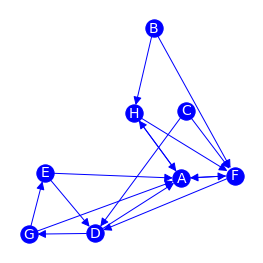

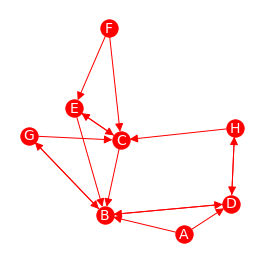

In [6]:
# create DiGraph A
Ga = nx.DiGraph()
Ga.add_edges_from(report_data["edges_a"])
Ga_info, Ga_data = get_network_stats(Ga)
report_data["ga_info"] = Ga_info
report_data["ga_data"] = Ga_data.to_dict("index")
report_data["ga_graph_uri"] = get_network_graph(Ga, "A")

# create DiGraph B
Gb = nx.DiGraph()
Gb.add_edges_from(report_data["edges_b"])
Gb_info, Gb_data = get_network_stats(Gb)
report_data["gb_info"] = Gb_info
report_data["gb_data"] = Gb_data.to_dict("index")
report_data["gb_graph_uri"] = get_network_graph(Gb, "B")

# get report template
tpl = e.get_template("ABGrid.html")

# render report
rendered_tpl = tpl.render(report_data);

# save report as pdf
HTML(string=rendered_tpl).write_pdf(f"ABGrid report - gruppo {report_data['group_id']}.pdf")